In [2]:
import pandas as pd # 数据表格工具
import numpy as np # 数值分析工具
import matplotlib.pyplot as plt # matplotlib绘图库
import plotly.express as px # plotly绘图库
%matplotlib inline

目标：选择一位最有价值的客户（消费多于1次），并分析该客户的购物情况或趋势。此外，对平台未来一段时间的销量进行预测。

# 1.数据导入

In [6]:
dtype = {
    "InvoiceNo": "string",
    "StockCode": "string",
    "Description": "string",
    "Quantity": "int32",
    "InvoiceDate":"string",
    "UnitPrice": "float32",
    "CustomerID": "string",
    "Country": "string"
}

filename = "./Online Retail.xlsx"
sales_success = pd.read_excel(filename, sheet_name='Online Retail', dtype=dtype, engine='calamine')

In [7]:
sales_success.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


# 2.数据预处理

由于选择对于最有价值的客户进行分析，此处准备对quantity列、unitprice列和customer列进行预处理，先借助描述性统计观察有无异常值。

In [12]:
print("Quantity列描述性统计：")
print("最大值：", sales_success['Quantity'].max())
print("最小值：", sales_success['Quantity'].min())
print("平均值：", sales_success['Quantity'].mean())

print("\nUnitPrice列描述性统计：")
print("最大值：", sales_success['UnitPrice'].max())
print("最小值：", sales_success['UnitPrice'].min())
print("平均值：", sales_success['UnitPrice'].mean())

print("\nCustomerID列空值数量：", sales_success['CustomerID'].isnull().sum())

Quantity列描述性统计：
最大值： 80995
最小值： -80995
平均值： 9.55224954743324

UnitPrice列描述性统计：
最大值： 38970.0
最小值： -11062.0595703125
平均值： 4.611114

CustomerID列空值数量： 135080


此处可以看出，quantity列与unitprice列明显有异常值存在，并且customerID列有空值，人工检查发现quantity的负值来源于退款订单，在考虑消费总额时应当保留，unitprice的异常值似乎来源于账目的处理，故直接不考虑这些值所在的行。此外，由于分析的对象是客户，customerID为空的行也一并舍去。

In [23]:
sales_customer = sales_success[(sales_success.UnitPrice > 0)&(sales_success.CustomerID.notna())].copy()
#print("清洗后数据量：", len(sales_customer)) 调试用
#print("\nCustomerID列空值数量：", sales_customer['CustomerID'].isnull().sum()) 调试用
sales_customer.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


# 3.客户数据分析

筛选后的数据存放在sales_customer中，而考虑到对客户分析最直观的数据是消费的总额，同时源数据中并未给出此数据，先对每条数据中实际产生的总销售金额进行计算。

In [27]:
sales_customer['SumPrice'] = sales_customer['Quantity'] * sales_customer['UnitPrice']
sales_customer.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SumPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.300000
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.340001
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.000000
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.340001
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.340001


只利用消费总金额识别最有价值的客户会忽略客户在时间维度上的区别，例如只在几年前大额消费过的客户，这样的客户对平台当前的价值并不高，因此考虑引入RFM模型进行最有价值客户的识别。

In [32]:
# 确保 InvoiceDate 是 datetime 类型
sales_customer['InvoiceDate'] = pd.to_datetime(sales_customer['InvoiceDate'])

# 获取整个数据集的最后一天（作为计算 Recency 的“今天”）
max_date = sales_customer['InvoiceDate'].max()

rfm = sales_customer.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (max_date - x.max()).days,   # Recency：最后一次购买距离今天的天数
    'InvoiceNo': 'nunique',                                # Frequency：唯一发票数
    'SumPrice': 'sum'                                      # Monetary：总消费金额
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'SumPrice': 'Monetary'
}).reset_index()

rfm.describe()

,Recency,Frequency,Monetary
count,4371.000000,4371.000000,4371.000000
mean,91.064974,5.075726,1898.894022
std,100.770046,9.332529,8220.235313
min,0.000000,1.000000,-4287.629883
25%,16.000000,1.000000,293.784998
50%,49.000000,3.000000,648.409998
75%,142.000000,5.000000,1611.859991
max,373.000000,248.000000,279489.019443


从结果中可以看出，由于此前删除了CustomerID缺失的数据行，导致清洗后的数据中出现了总消费金额为负（实际上不可能）的顾客，因此要再剔除消费金额为负的客户以免影响后续RFM模型的分箱。

In [47]:
# 剔除 Monetary ≤ 0 的客户
rfm_positive = rfm[rfm['Monetary'] > 0].copy()

# 定义分箱函数
def r_score(x, p):
    if x <= p[0.2]:
        return 5
    elif x <= p[0.4]:
        return 4
    elif x <= p[0.6]:
        return 3
    elif x <= p[0.8]:
        return 2
    else:
        return 1

def fm_score(x, p):
    if x >= p[0.8]:
        return 5
    elif x >= p[0.6]:
        return 4
    elif x >= p[0.4]:
        return 3
    elif x >= p[0.2]:
        return 2
    else:
        return 1

# 计算分位数
r_quantiles = rfm_positive['Recency'].quantile([0.2, 0.4, 0.6, 0.8])
f_quantiles = rfm_positive['Frequency'].quantile([0.2, 0.4, 0.6, 0.8])
m_quantiles = rfm_positive['Monetary'].quantile([0.2, 0.4, 0.6, 0.8])

# 应用评分
rfm_positive['R_score'] = rfm_positive['Recency'].apply(r_score, p=r_quantiles)
rfm_positive['F_score'] = rfm_positive['Frequency'].apply(fm_score, p=f_quantiles)
rfm_positive['M_score'] = rfm_positive['Monetary'].apply(fm_score, p=m_quantiles)

In [49]:
rfm_positive['RFM_score'] = rfm_positive['R_score'] + rfm_positive['F_score'] + rfm_positive['M_score']
rfm_positive['RFM_segment'] = rfm_positive['R_score'].astype(str) + rfm_positive['F_score'].astype(str) + rfm_positive['M_score'].astype(str)
rfm_positive.describe()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
count,4318.000000,4318.000000,4.318000e+03,4318.000000,4318.000000,4318.000000,4318.000000
mean,89.360584,5.117879,1.925265e+03,3.006484,3.314729,3.000000,9.321214
std,99.148508,9.381190,8.266747e+03,1.416981,1.105641,1.414541,3.335793
min,0.000000,1.000000,9.536743e-07,1.000000,2.000000,1.000000,4.000000
25%,16.000000,1.000000,3.026100e+02,2.000000,2.000000,2.000000,7.000000
50%,48.000000,3.000000,6.580800e+02,3.000000,3.000000,3.000000,9.000000
75%,137.000000,6.000000,1.626840e+03,4.000000,4.000000,4.000000,12.000000
max,373.000000,248.000000,2.794890e+05,5.000000,5.000000,5.000000,15.000000


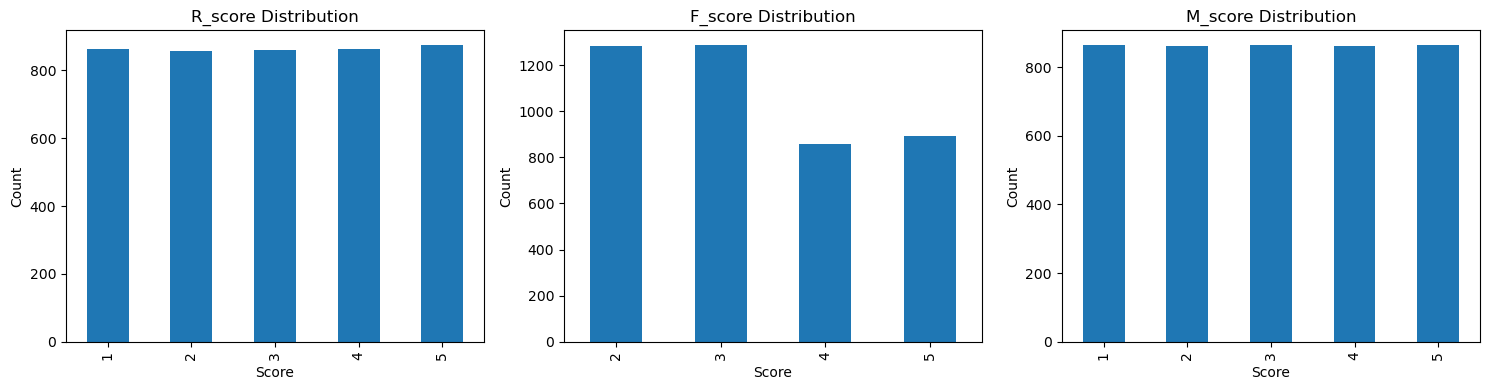

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['R_score', 'F_score', 'M_score']):
    rfm_positive[col].value_counts().sort_index().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

可以发现在F_score上，所有客户都得到了两分以上，这可能是因为Frequency的20%分位数等于最小值，但这一情况并不影响我们寻找最有价值的客户，因此忽略这一情况，开始寻找得分最高的用户。

In [58]:
# 按 RFM_score 降序，查看前10名
top_customers = rfm_positive.sort_values('RFM_score', ascending=False).head(10)
print(top_customers[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RFM_score', 'RFM_segment']])

# 筛选出 '555' 客户（三个维度都满分）
best_segment = rfm_positive[rfm_positive['RFM_segment'] == '555']
print(f"\nNumber of 555 customers: {len(best_segment)}")
best_segment.head()

     CustomerID  Recency  Frequency      Monetary  RFM_score RFM_segment
1         12347        1          7   4309.999988         15         555
3504      17090        3          8   2041.849976         15         555
793       13394        1         10   2312.799983         15         555
802       13408        1         81  27487.409850         15         555
3281      16782        9         19   2242.249993         15         555
3278      16779        1         28  10454.049980         15         555
814       13426        0         12   3550.699981         15         555
3264      16764        3         18   2758.249983         15         555
821       13435        4          9   3794.489979         15         555
3248      16746        4         19   6694.309923         15         555

Number of 555 customers: 346


,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment
1,12347,1,7,4309.999988,5,5,5,15,555
15,12362,2,13,5154.580000,5,5,5,15,555
56,12417,2,12,3578.799994,5,5,5,15,555
71,12433,0,7,13375.869885,5,5,5,15,555
75,12437,1,19,4896.659983,5,5,5,15,555


对这346名顾客再做统计，寻找其中最突出的客户。由于Recency的偶然性较高，并且差距很小（0-16），优先考虑从Frequency和Monetary入手。

In [66]:
# 消费金额最多的顾客
top_monetary_customer = best_segment.sort_values('Monetary', ascending=False).head(5)

# 购买频率最高的顾客
top_frequency_customer = best_segment.sort_values('Frequency', ascending=False).head(5)

print("消费金额最多的顾客：")
print(top_monetary_customer)

print("购买频率最高的顾客：")
print(top_frequency_customer)

消费金额最多的顾客：
     CustomerID  Recency  Frequency       Monetary  R_score  F_score  M_score  \
1702      14646        1         76  279489.019443        5        5        5   
4232      18102        0         62  256438.488361        5        5        5   
3757      17450        7         55  187482.170972        5        5        5   
1894      14911        0        248  132572.619278        5        5        5   
1344      14156        9         66  113384.139510        5        5        5   

      RFM_score RFM_segment  
1702         15         555  
4232         15         555  
3757         15         555  
1894         15         555  
1344         15         555  
购买频率最高的顾客：
     CustomerID  Recency  Frequency       Monetary  R_score  F_score  M_score  \
1894      14911        0        248  132572.619278        5        5        5   
330       12748        0        223   29072.099826        5        5        5   
4041      17841        1        169   40340.779700        5        5

从数据中看出，并没有在Frequency和Monetary指标上都突出的客户，因此进行Z-score对两个数据进行标准化，将标准化后的结果等权重相加作为一个综合指标，取得分最高的客户作为最有价值的客户。

In [72]:
from sklearn.preprocessing import StandardScaler
# 筛选出 555 客户
df_555 = rfm_positive[rfm_positive['RFM_segment'] == '555'].copy()

# 选择 Frequency 和 Monetary 列
X = df_555[['Frequency', 'Monetary']]

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 计算综合得分（等权重相加）
df_555['combined_score'] = X_scaled[:, 0] + X_scaled[:, 1]

# 按综合得分排序
top_combined = df_555.sort_values('combined_score', ascending=False).head(10)
print(top_combined[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'combined_score']])

     CustomerID  Recency  Frequency       Monetary  combined_score
1894      14911        0        248  132572.619278       13.871988
1702      14646        1         76  279489.019443       12.501534
4232      18102        0         62  256438.488361       11.045681
330       12748        0        223   29072.099826        8.878499
3757      17450        7         55  187482.170972        8.112458
4041      17841        1        169   40340.779700        7.109795
2191      15311        0        118   59419.339351        5.763284
1344      14156        9         66  113384.139510        5.715603
568       13089        2        118   57385.879820        5.685201
1673      14606        0        128   11713.849898        4.339109


从结果判断，将CustomerID为14911的顾客选为最有价值的客户，并进行后续的分析。

In [75]:
customer_14911 = sales_customer[sales_customer['CustomerID'] == '14911'].copy()
customer_14911['InvoiceDate'] = pd.to_datetime(customer_14911['InvoiceDate'])
customer_14911 = customer_14911.sort_values('InvoiceDate')
customer_14911.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SumPrice
1404,536540,22968,ROSE COTTAGE KEEPSAKE BOX,4,2010-12-01 14:05:00,9.95,14911,EIRE,39.799999
1424,536541,21915,RED HARMONICA IN BOX,12,2010-12-01 14:05:00,1.25,14911,EIRE,15.000000
1423,536540,C2,CARRIAGE,1,2010-12-01 14:05:00,50.00,14911,EIRE,50.000000
1421,536540,21891,TRADITIONAL WOODEN SKIPPING ROPE,12,2010-12-01 14:05:00,1.25,14911,EIRE,15.000000
1420,536540,21889,WOODEN BOX OF DOMINOES,24,2010-12-01 14:05:00,1.25,14911,EIRE,30.000000
1419,536540,21056,DOCTOR'S BAG SOFT TOY,4,2010-12-01 14:05:00,8.95,14911,EIRE,35.799999
1418,536540,21055,TOOL BOX SOFT TOY,4,2010-12-01 14:05:00,8.95,14911,EIRE,35.799999
1417,536540,85136C,RED SHARK HELICOPTER,2,2010-12-01 14:05:00,7.95,14911,EIRE,15.900000
1416,536540,85136A,YELLOW SHARK HELICOPTER,2,2010-12-01 14:05:00,7.95,14911,EIRE,15.900000
1415,536540,85135B,BLUE DRAGONFLY HELICOPTER,2,2010-12-01 14:05:00,7.95,14911,EIRE,15.900000


对顾客14911的购物趋势按月进行统计，并进行绘图，绘制消费金额、订单数量和购买件数关于时间的折线图。

In [78]:
customer_14911['Month'] = customer_14911['InvoiceDate'].dt.to_period('M')
monthly_stats = customer_14911.groupby('Month').agg(
    OrderCount=('InvoiceNo', 'nunique'),
    TotalAmount=('SumPrice', 'sum'),
    TotalQuantity=('Quantity', 'sum')
).reset_index()
monthly_stats.head()

,Month,OrderCount,TotalAmount,TotalQuantity
0,2010-12,16,6757.129987,2928
1,2011-01,7,4896.799957,2494
2,2011-02,5,1445.389996,682
3,2011-03,18,7053.049961,4310
4,2011-04,8,4572.319987,2588


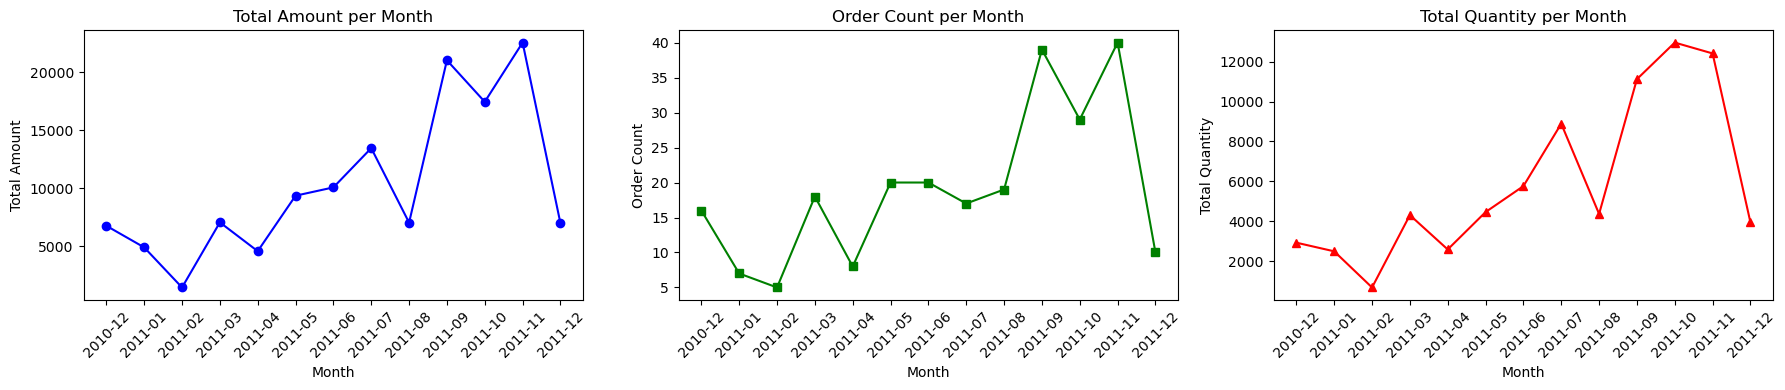

In [84]:
# 生成月份字符串列表（用于横坐标）
months = monthly_stats['Month'].astype(str)

# 创建1行3列的子图，调整画布大小以适应并排显示
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 子图1：总消费金额
axes[0].plot(months, monthly_stats['TotalAmount'], marker='o', color='blue')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Amount')
axes[0].set_title('Total Amount per Month')
axes[0].tick_params(axis='x', rotation=45)

# 子图2：订单数量
axes[1].plot(months, monthly_stats['OrderCount'], marker='s', color='green')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Order Count')
axes[1].set_title('Order Count per Month')
axes[1].tick_params(axis='x', rotation=45)

# 子图3：总购买件数
axes[2].plot(months, monthly_stats['TotalQuantity'], marker='^', color='red')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Total Quantity')
axes[2].set_title('Total Quantity per Month')
axes[2].tick_params(axis='x', rotation=45)

# 自动调整子图间距，防止标签重叠
plt.tight_layout()
plt.show()

除了上述统计展现出的购物情况总计，还可分析其购买件数最多的商品。

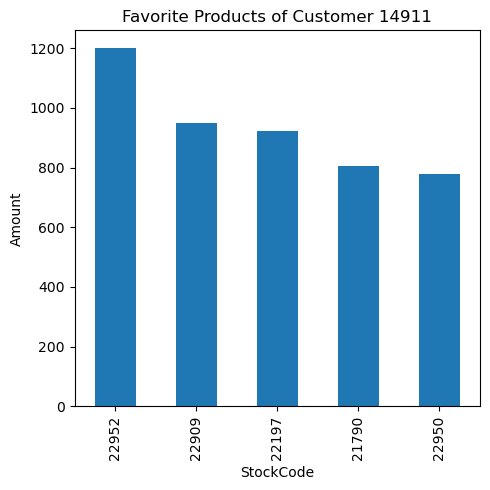

In [87]:
top_products = customer_14911.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(5,5))
top_products.plot(kind='bar')
plt.title('Favorite Products of Customer 14911')
plt.ylabel('Amount')
plt.xlabel('StockCode')
plt.tight_layout()
plt.show()

# 4.平台销售量预测

In [89]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima

考虑按月进行商品销售量的统计，为方便后续操作直接将月份设为索引，并取各月销售量作为时间序列数据。

In [98]:
# ========== 1. 准备数据 ==========
# ts 是已有的月度销售量 Series（索引为日期）
sales_customer['InvoiceDate'] = pd.to_datetime(sales_customer['InvoiceDate'])
sales_customer['Month'] = sales_customer['InvoiceDate'].dt.to_period('M')
platform_monthly = sales_customer.groupby('Month')['Quantity'].sum().reset_index()
platform_monthly['Month'] = platform_monthly['Month'].dt.to_timestamp()
platform_monthly = platform_monthly.set_index('Month')
ts = platform_monthly['Quantity']
# 由于数据只有13个月，我们取前11个月训练，最后2个月测试
train = ts.iloc[:-2]      # 2010-12 至 2011-10（假设最后两个月是 2011-11, 2011-12）
test = ts.iloc[-2:]       # 最后两个月作为测试

In [100]:
# ========== 2. 自动选择最佳 ARIMA 参数（非季节性） ==========
print("正在自动搜索最佳 ARIMA 参数...")
auto_model = auto_arima(
    train,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    seasonal=False,        # 数据量小，不启用季节性
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(auto_model.summary())

# 获取最优参数
best_order = auto_model.order
print(f"最佳参数: {best_order}")

正在自动搜索最佳 ARIMA 参数...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=315.829, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=313.292, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=285.817, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=287.356, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=305.017, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.01 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.06 sec

Best model:  ARIMA(1,0,1)(0,0,0)[0]          
Total fit time: 0.494 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   11
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -

In [102]:
# ========== 3. 用最佳参数拟合 ARIMA 模型 ==========
model = ARIMA(train, order=best_order)
model_fit = model.fit()

# 输出模型摘要
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:               Quantity   No. Observations:                   11
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -138.232
Date:                Fri, 13 Mar 2026   AIC                            284.464
Time:                        16:37:56   BIC                            286.056
Sample:                    12-01-2010   HQIC                           283.461
                         - 10-01-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.666e+05    1.2e+05      3.050      0.002    1.31e+05    6.02e+05
ar.L1          0.7889      0.596      1.323      0.186      -0.380       1.958
ma.L1          0.0315      0.812      0.039      0.9

F:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
F:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
F:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


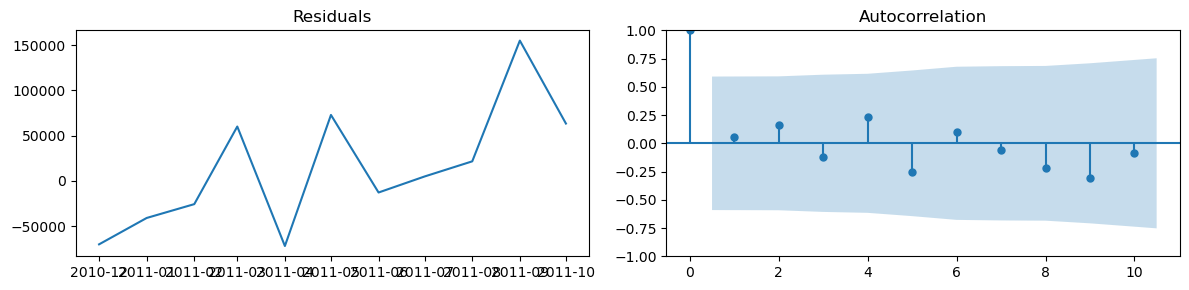

In [104]:
# ========== 4. 残差检验 ==========
resid = model_fit.resid
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].plot(resid)
ax[0].set_title('Residuals')
plot_acf(resid, lags=10, ax=ax[1])
plt.tight_layout()
plt.show()
# 若残差无自相关（ACF 值基本在置信区间内），则模型可接受。

In [106]:
# ========== 5. 预测测试集并评估 ==========
pred = model_fit.forecast(steps=len(test))

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
print(f"测试集 MAE : {mae:.2f}")
print(f"测试集 RMSE: {rmse:.2f}")


测试集 MAE : 209497.26
测试集 RMSE: 224680.58


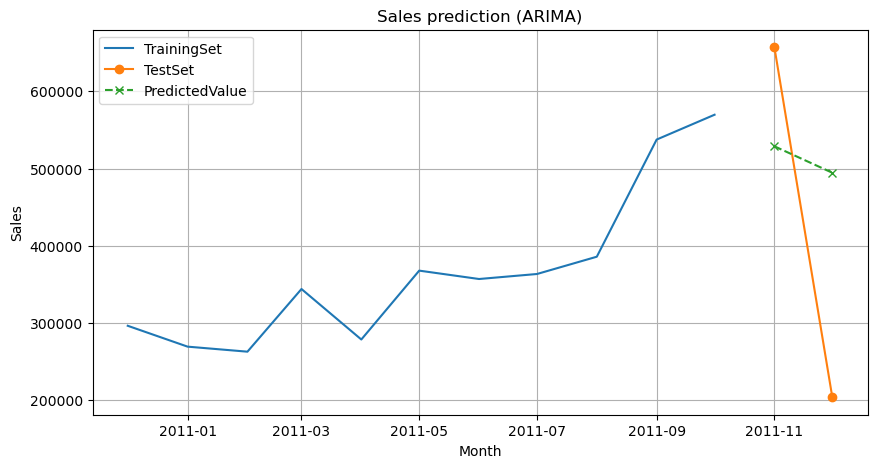

In [114]:
# 绘制训练、测试、预测对比图
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='TrainingSet')
plt.plot(test.index, test, label='TestSet', marker='o')
plt.plot(test.index, pred, label='PredictedValue', marker='x', linestyle='--')
plt.legend()
plt.title('Sales prediction (ARIMA)')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()


结合报错信息可以看出，由于数据的时间跨度以月为单位时（共13个月）有些不足，模型训练的效果并不好，但数据集只有这么大，因此考虑换为按周聚合重新训练。

In [118]:
# 从清洗后的数据中准备原始交易记录（使用 sales_customer）
# 确保 InvoiceDate 为 datetime 类型
sales_customer['InvoiceDate'] = pd.to_datetime(sales_customer['InvoiceDate'])

# 设置日期为索引，并按周重采样求和销售量（以每周日为结束，可调整）
weekly_sales = sales_customer.set_index('InvoiceDate')['Quantity'].resample('W').sum()

# 查看数据概览
print(f"周数据样本量：{len(weekly_sales)}")
print(weekly_sales.head(10))

周数据样本量：54
InvoiceDate
2010-12-05    72828
2010-12-12    99574
2010-12-19    94241
2010-12-26    29704
2011-01-02        0
2011-01-09    68578
2011-01-16    76435
2011-01-23    56575
2011-01-30    56163
2011-02-06    63990
Freq: W-SUN, Name: Quantity, dtype: int32


In [120]:
# 将周销售量 Series 命名为 ts_weekly
ts_weekly = weekly_sales

# 划分训练集和测试集（留最后 4 周作为测试，共约 52 周）
train_weekly = ts_weekly.iloc[:-4]
test_weekly = ts_weekly.iloc[-4:]

print(f"训练集：{train_weekly.index[0]} 至 {train_weekly.index[-1]}")
print(f"测试集：{test_weekly.index[0]} 至 {test_weekly.index[-1]}")

训练集：2010-12-05 00:00:00 至 2011-11-13 00:00:00
测试集：2011-11-20 00:00:00 至 2011-12-11 00:00:00


In [122]:
# ========== 自动搜索最佳 ARIMA 参数（尝试季节性，周期 7） ==========
print("正在自动搜索最佳 ARIMA 参数...")
auto_model_weekly = auto_arima(
    train_weekly,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    seasonal=True,          # 尝试季节性
    m=7,                     # 周周期（7 天）
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(auto_model_weekly.summary())
best_order_weekly = auto_model_weekly.order
best_seasonal_order_weekly = auto_model_weekly.seasonal_order
print(f"最佳非季节参数: {best_order_weekly}")
print(f"最佳季节参数: {best_seasonal_order_weekly}")

正在自动搜索最佳 ARIMA 参数...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=1142.019, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=1141.961, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=1131.010, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=1140.211, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=1129.057, Time=0.05 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=1136.302, Time=0.04 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=1139.794, Time=0.04 sec
 ARIMA(0,1,2)(0,0,0)[7] intercept   : AIC=1144.978, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=1140.392, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[7] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[7]             : AIC=1131.493, Time=0.02 sec

Best model:  ARIMA(0,1,1)(0,0,0)[7] intercept
Total fit time: 0.620 seconds
                               SARIMAX Results                               

In [124]:
# ========== 用最佳参数拟合 SARIMA 模型 ==========
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_weekly = SARIMAX(
    train_weekly,
    order=best_order_weekly,
    seasonal_order=best_seasonal_order_weekly,
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit_weekly = model_weekly.fit(disp=False)
print(model_fit_weekly.summary())

                               SARIMAX Results                                
Dep. Variable:               Quantity   No. Observations:                   50
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -539.207
Date:                Fri, 13 Mar 2026   AIC                           1082.414
Time:                        16:49:36   BIC                           1086.114
Sample:                    12-05-2010   HQIC                          1083.806
                         - 11-13-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.5268      0.068    -22.521      0.000      -1.660      -1.394
sigma2      4.353e+08    2.1e-11   2.08e+19      0.000    4.35e+08    4.35e+08
Ljung-Box (L1) (Q):                   0.05   Jarque-

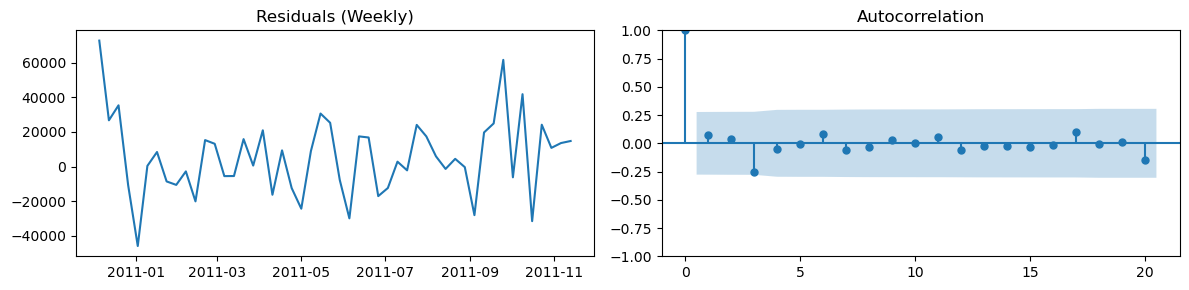

In [126]:
# ========== 残差检验 ==========
resid_weekly = model_fit_weekly.resid
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].plot(resid_weekly)
ax[0].set_title('Residuals (Weekly)')
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(resid_weekly, lags=20, ax=ax[1])
plt.tight_layout()
plt.show()

In [128]:
# ========== 预测测试集并评估 ==========
pred_weekly = model_fit_weekly.forecast(steps=len(test_weekly))

mae_weekly = mean_absolute_error(test_weekly, pred_weekly)
rmse_weekly = np.sqrt(mean_squared_error(test_weekly, pred_weekly))
print(f"周数据测试集 MAE : {mae_weekly:.2f}")
print(f"周数据测试集 RMSE: {rmse_weekly:.2f}")


周数据测试集 MAE : 5303.48
周数据测试集 RMSE: 6836.99


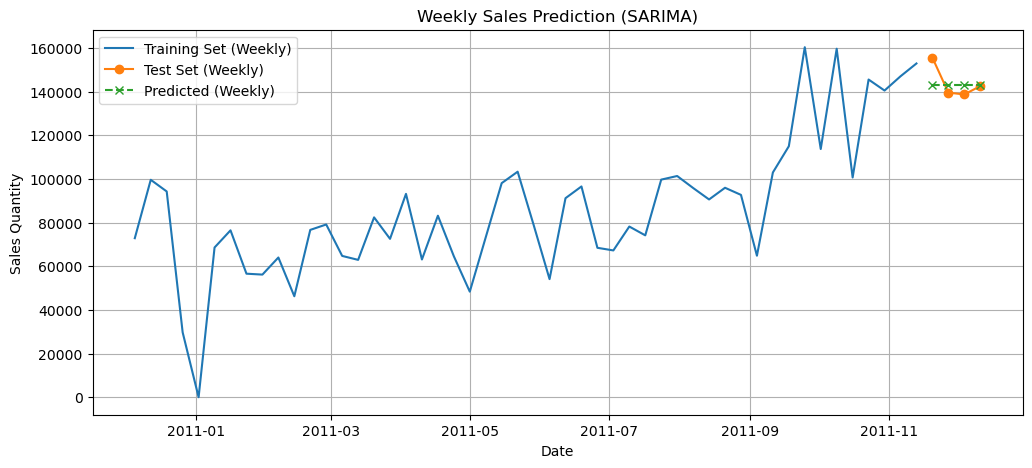

In [130]:
# 绘制训练、测试、预测对比图
plt.figure(figsize=(12, 5))
plt.plot(train_weekly.index, train_weekly, label='Training Set (Weekly)')
plt.plot(test_weekly.index, test_weekly, label='Test Set (Weekly)', marker='o')
plt.plot(test_weekly.index, pred_weekly, label='Predicted (Weekly)', marker='x', linestyle='--')
plt.legend()
plt.title('Weekly Sales Prediction (SARIMA)')
plt.xlabel('Date')
plt.ylabel('Sales Quantity')
plt.grid(True)
plt.show()